In [75]:
HOLOGRAM_LETTER = "T"

Generated 50x50 matrix for the letter 'T':


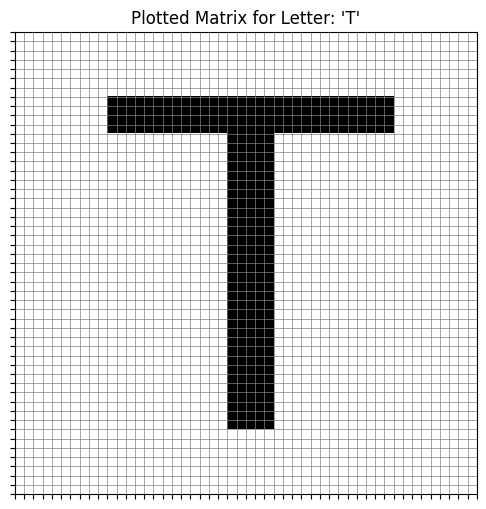

In [76]:
# GENERATE LETTER MATRIX FOR HOLOGRAM

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

def letter_to_matrix(letter, matrix_size=20):
    """
    Generates a square binary matrix that visually represents a given letter,
    scaling the letter to be as large as possible within the matrix.

    Args:
        letter (str): The single character to convert into a matrix.
        matrix_size (int): The width and height of the square matrix.

    Returns:
        np.ndarray: A square NumPy array of 0s and 1s representing the letter.
    """
    if len(letter) != 1:
        raise ValueError("Please provide a single character.")

    # Create a new black image (0) with the given size. Mode 'L' is for grayscale.
    image = Image.new('L', (matrix_size, matrix_size), 0)
    draw = ImageDraw.Draw(image)

    # --- Font Selection ---
    # Find the best font size by starting large and reducing until the letter fits.
    font_size = matrix_size
    font = None

    while font_size > 0:
        try:
            # You can specify a path to a .ttf file, e.g., font = ImageFont.truetype("arial.ttf", font_size)
            font = ImageFont.truetype("DejaVuSans.ttf", font_size)
        except IOError:
            print("Default font not found, using Pillow's default. For better results, install a standard font or provide a path to a .ttf file.")
            font = ImageFont.load_default()
            # Pillow's default font is not scalable, so we must break the loop.
            break

        # Get the bounding box of the letter to check its rendered size
        bbox = draw.textbbox((0, 0), letter, font=font)
        text_width = bbox[2] - bbox[0]
        text_height = bbox[3] - bbox[1]

        # If the rendered letter fits within the matrix dimensions, we've found our font size.
        if text_width <= matrix_size and text_height <= matrix_size:
            break
        
        # Otherwise, reduce font size and try again.
        font_size -= 1
    
    if font is None: # Fallback if no font could be loaded
        font = ImageFont.load_default()

    # --- Text Positioning ---
    # Recalculate the bounding box with the final, optimal font size
    bbox = draw.textbbox((0, 0), letter, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    
    # Calculate position to center the letter.
    # We subtract the bbox's top-left coordinates to account for the font's internal offsets.
    position_x = (matrix_size - text_width) / 2 - bbox[0]
    position_y = (matrix_size - text_height) / 2 - bbox[1]
    
    # Draw the letter onto the image in white (255)
    draw.text((position_x, position_y), letter, font=font, fill=255)

    # Convert the Pillow image to a NumPy array
    matrix = np.array(image)

    # Convert the grayscale array (0-255) to a binary array (0 or 1)
    binary_matrix = (matrix > 128).astype(int)

    return binary_matrix

# --- Example Usage ---
if __name__ == '__main__':
    # --- User-defined variables ---
    letter_to_generate = HOLOGRAM_LETTER  # Change this to any letter you want to generate
    matrix_dimension = 50

    # Generate the matrix
    letter_matrix = letter_to_matrix(letter_to_generate, matrix_size=matrix_dimension)

    # --- Visualization ---
    print(f"Generated {matrix_dimension}x{matrix_dimension} matrix for the letter '{letter_to_generate}':")

    plt.figure(figsize=(6, 6))

    plt.imshow(letter_matrix, cmap='gray_r', interpolation='nearest')
    plt.title(f"Plotted Matrix for Letter: '{letter_to_generate}'")
    # Add grid lines to show the individual matrix cells
    plt.xticks(np.arange(-.5, matrix_dimension, 1), [])
    plt.yticks(np.arange(-.5, matrix_dimension, 1), [])
    plt.grid(True, color='gray', linestyle='-', linewidth=0.5)
    plt.show()


In [77]:
# SIMULATED CAMERA (stand-in for capture_camera_image)
# Lets the ASPGD notebook run end-to-end with no hardware attached.

def camera_extent(d, wavelength):
    """
    Says how far off-axis the edge of the simulated camera is.

    Use this to label the far-field plots. The angular size of the pattern is set
    by the emitter spacing, so it changes whenever d changes.

    This is exact rather than a small-angle approximation, because the far field
    really is uniform in sin(angle). If you want the size of the pattern on a
    flat screen a distance L away, that is L * np.tan(camera_extent(d, wavelength)).

    Returns:
        float: The angle in radians between the optical axis and the edge of the
        image.
    """
    max_sin = wavelength / (2 * d)

    return np.arcsin(np.clip(max_sin, -1.0, 1.0))


def propagate_beams(phases, N, resolution):
    """
    Simulates the camera image produced by an N x N array of phase-controlled emitters.

    Every emitter sends out light with the same brightness but its own phase.
    Far from the array all those waves overlap and interfere: in directions where
    they arrive in step they add up to a bright spot, and in directions where they
    arrive out of step they cancel. Changing the phases rearranges the pattern,
    which is what the ASPGD optimizer takes advantage of.

    That far-field pattern is the Fourier transform of the emitter plane, so the
    whole propagation is a single FFT. The camera covers exactly one repeat of the
    pattern. d and wavelength set how wide that repeat is in angle, which is what
    camera_extent reports, but they do not change the shape of the image.

    Args:
        phases (np.array): N x N array of phase shifts, in radians.
        N (int): Number of emitters along each side of the square array.
        resolution (int): The camera is resolution x resolution pixels.

    Returns:
        tuple: (norm_intensity, field)
            norm_intensity: resolution x resolution brightness, scaled so the
                brightest pixel is 1. This is what a camera would record.
            field: resolution x resolution complex light field. A camera cannot
                measure this, but it is useful for debugging.
    """
    phases = np.asarray(phases).reshape(N, N)

    # --- 1. The emitter plane ---
    # Rows of the camera image are y and columns are x, so the emitters are laid
    # out the same way: the row index picks the y emitter, the column index the x
    # one. Everything around them is empty space, which is the zero padding.
    aperture = np.zeros((resolution, resolution), dtype=complex)
    aperture[:N, :N] = np.exp(1j * phases).T

    # --- 2. Propagate to the far field ---
    # The far field is the Fourier transform of the emitter plane. fftshift then
    # moves the straight-ahead direction to the middle of the image.
    field = np.fft.fftshift(np.fft.fft2(aperture))
    pixel_index = np.arange(resolution) - resolution // 2
    tilt = np.exp(2j * np.pi * pixel_index * (N - 1) / (2 * resolution))
    field = field * tilt[:, np.newaxis] * tilt[np.newaxis, :]

    # --- 3. What the camera sees ---
    # A camera measures brightness, which is the squared magnitude of the field.
    intensity = np.abs(field) ** 2

    # Scale so the brightest pixel is 1, like a normalized camera frame.
    norm_intensity = intensity / intensity.max()
    return norm_intensity, field

Iteration 1/1500, Cosine Similarity: 0.2024
Iteration 2/1500, Cosine Similarity: 0.2011
Iteration 3/1500, Cosine Similarity: 0.2047
Iteration 4/1500, Cosine Similarity: 0.2057
Iteration 5/1500, Cosine Similarity: 0.2138
Iteration 6/1500, Cosine Similarity: 0.2176
Iteration 7/1500, Cosine Similarity: 0.2200
Iteration 8/1500, Cosine Similarity: 0.2244
Iteration 9/1500, Cosine Similarity: 0.2277
Iteration 10/1500, Cosine Similarity: 0.2313
Iteration 11/1500, Cosine Similarity: 0.2354
Iteration 12/1500, Cosine Similarity: 0.2401
Iteration 13/1500, Cosine Similarity: 0.2424
Iteration 14/1500, Cosine Similarity: 0.2458
Iteration 15/1500, Cosine Similarity: 0.2487
Iteration 16/1500, Cosine Similarity: 0.2534
Iteration 17/1500, Cosine Similarity: 0.2566
Iteration 18/1500, Cosine Similarity: 0.2621
Iteration 19/1500, Cosine Similarity: 0.2632
Iteration 20/1500, Cosine Similarity: 0.2673
Iteration 21/1500, Cosine Similarity: 0.2703
Iteration 22/1500, Cosine Similarity: 0.2746
Iteration 23/1500, 

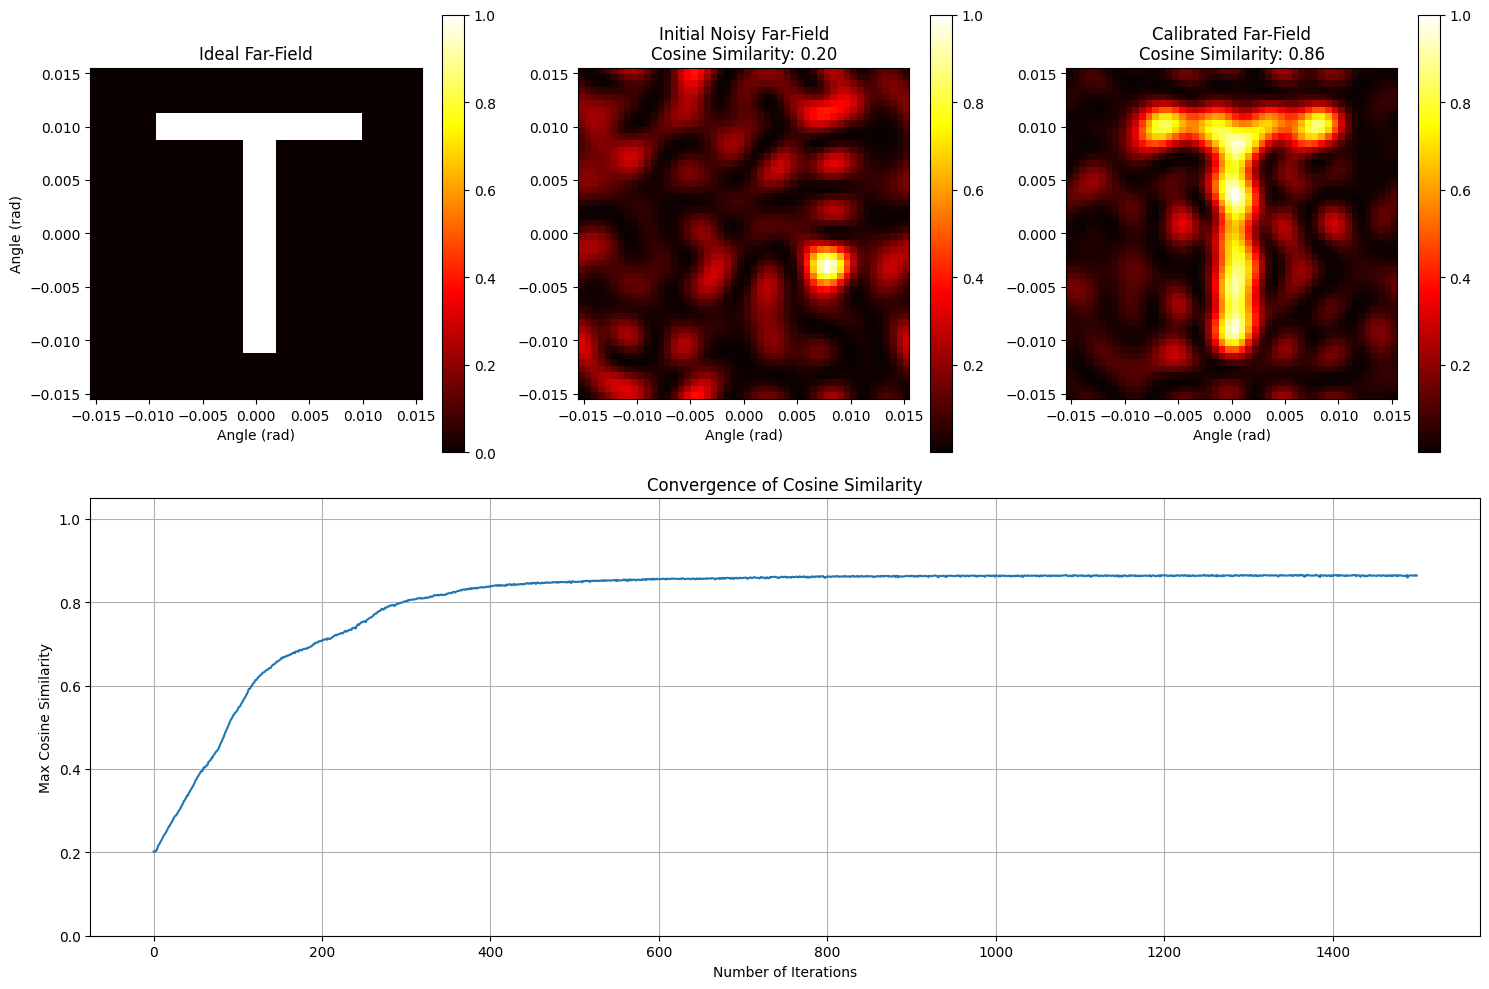

In [78]:
# PHASE CALIBRATION USING ASPGD
# This code implements the ASPGD algorithm to calibrate the phase of a spatial light modulator

import numpy as np
import matplotlib.pyplot as plt

def calculate_far_field(phases, N, resolution, d, wavelength):
    """
    Calculates the far-field intensity pattern of an N x N SLM.

    This function simulates the physical process of light diffraction and 
    interference that occurs when a coherent light source passes through 
    a spatial light modulator (SLM). The far-field pattern is essentially 
    the Fourier transform of the near-field pattern at the SLM.

    Args:
        phases (np.array): A 2D numpy array of phase values for each element of the SLM. 
                         These values represent the phase shift applied to the light at each point.
        N (int): The number of elements along each side of the square SLM.
        resolution (int): The resolution of the far-field camera (resolution x resolution).
        d (float): The spacing between the SLM elements.
        wavelength (float): The wavelength of the light used in the simulation.

    Returns:
        np.array: A 2D numpy array representing the normalized far-field intensity pattern.
    """

    # propagate_beams is a dummy function that simulates the propagation of light from the SLM to the far-field screen.
    # Replace this with the camera capture function in a real-world application.

    norm_intensity, _ = propagate_beams(phases, N, resolution)
    return norm_intensity

def cosine_similarity(ideal_field, actual_field):
    """
    Calculates the cosine similarity between two far-field patterns.

    Cosine similarity is used here as the objective function to quantify how well the 
    calibrated far-field pattern matches the ideal pattern. A value close to 1 indicates 
    a high degree of similarity.

    Args:
        ideal_field (np.array): The ideal far-field pattern that we are trying to achieve.
        actual_field (np.array): The actual far-field pattern produced by the SLM.

    Returns:
        float: The cosine similarity value, which ranges from 0 to 1.
    """
    ideal_flat = ideal_field.flatten()
    actual_flat = actual_field.flatten()
    
    dot_product = np.dot(ideal_flat, actual_flat)
    norm_ideal = np.linalg.norm(ideal_flat)
    norm_actual = np.linalg.norm(actual_flat)
    
    # Avoid division by zero if either norm is zero
    if norm_ideal == 0 or norm_actual == 0:
        return 0.0
        
    return dot_product / (norm_ideal * norm_actual)

def run_aspgd_simulation():
    """
    Runs the full ASPGD simulation and plots the results.

    This function orchestrates the entire simulation process. It sets up the initial 
    parameters, runs the optimization loop, and then visualizes the results to 
    demonstrate the effectiveness of the ASPGD algorithm.
    """
    # --- Simulation Parameters ---
    N = 8  # 8x8 SLM
    FAR_FIELD_RES = 50 # 50x50 camera resolution
    WAVELENGTH = 1550e-9
    ELEMENT_SPACING = 50e-6 # pixel pitch for dummy simulation

    # --- ASPGD Hyperparameters ---
    ALPHA = 0.05  # Learning rate
    BETA_1 = 0.9
    BETA_2 = 0.999
    EPSILON = 1e-8
    ITERATIONS = 1500
    
    # --- Initialization ---
    # Noisy phase represents the initial state with random errors
    phases_noisy = np.random.uniform(0, 2 * np.pi, (N, N))
    phases_current = np.copy(phases_noisy)

    # Adam optimizer variables
    m = np.zeros((N, N))
    v = np.zeros((N, N))
    
    # --- Generate Ideal and Initial Fields ---
    far_field_ideal = letter_matrix
    far_field_initial_noisy = calculate_far_field(phases_noisy, N, FAR_FIELD_RES, ELEMENT_SPACING, WAVELENGTH)
    
    # --- Main Optimization Loop ---
    history = []
    initial_similarity = cosine_similarity(far_field_ideal, far_field_initial_noisy)
    history.append(initial_similarity)
    
    for n in range(1, ITERATIONS + 1):
        # Generate random perturbations for gradient approximation
        delta_u = np.random.randn(N, N) * 0.1

        # Calculate objective function for positive and negative perturbations
        J_plus = cosine_similarity(far_field_ideal, calculate_far_field(phases_current + delta_u, N, FAR_FIELD_RES, ELEMENT_SPACING, WAVELENGTH))
        J_minus = cosine_similarity(far_field_ideal, calculate_far_field(phases_current - delta_u, N, FAR_FIELD_RES, ELEMENT_SPACING, WAVELENGTH))
        
        # Approximate the gradient using the finite difference method
        grad = delta_u * (J_plus - J_minus) / 2.0
        
        # Update Adam moments
        m = BETA_1 * m + (1 - BETA_1) * grad
        v = BETA_2 * v + (1 - BETA_2) * (grad**2)
        
        # Bias correction for Adam moments
        m_hat = m / (1 - BETA_1**n)
        v_hat = v / (1 - BETA_2**n)
        
        # Update the phase values using the Adam update rule for gradient ASCENT
        phases_current += ALPHA * m_hat / (np.sqrt(v_hat) + EPSILON)

        # Record the current cosine similarity for plotting the convergence
        current_similarity = (J_plus + J_minus) / 2.0  # Average of positive and negative perturbations
        history.append(current_similarity)

        if n % 1 == 0 or n == ITERATIONS:
            print(f"Iteration {n}/{ITERATIONS}, Cosine Similarity: {history[-1]:.4f}")

    # --- Final Calibrated Field ---
    far_field_calibrated = calculate_far_field(phases_current, N, FAR_FIELD_RES, ELEMENT_SPACING, WAVELENGTH)

    # --- Plotting Results ---
    # The angular size of the pattern is set by the emitter spacing, so ask the
    # simulator where the edge of the camera really is rather than assuming it.
    max_angle = camera_extent(ELEMENT_SPACING, WAVELENGTH)
    angular_extent = [-max_angle, max_angle, -max_angle, max_angle]

    fig = plt.figure(figsize=(15, 10))
    
    # Plotting the far-field patterns
    ax1 = fig.add_subplot(2, 3, 1)
    im1 = ax1.imshow(far_field_ideal, cmap='hot', extent=angular_extent)
    ax1.set_title(f"Ideal Far-Field")
    ax1.set_xlabel("Angle (rad)")
    ax1.set_ylabel("Angle (rad)")
    fig.colorbar(im1, ax=ax1)

    ax2 = fig.add_subplot(2, 3, 2)
    im2 = ax2.imshow(far_field_initial_noisy, cmap='hot', extent=angular_extent)
    ax2.set_title(f"Initial Noisy Far-Field\nCosine Similarity: {initial_similarity:.2f}")
    ax2.set_xlabel("Angle (rad)")
    fig.colorbar(im2, ax=ax2)

    ax3 = fig.add_subplot(2, 3, 3)
    im3 = ax3.imshow(far_field_calibrated, cmap='hot', extent=angular_extent)
    ax3.set_title(f"Calibrated Far-Field\nCosine Similarity: {history[-1]:.2f}")
    ax3.set_xlabel("Angle (rad)")
    fig.colorbar(im3, ax=ax3)
    
    # Plotting the convergence of the algorithm
    ax4 = fig.add_subplot(2, 1, 2)
    ax4.plot(history)
    ax4.grid(True)
    ax4.set_title("Convergence of Cosine Similarity")
    ax4.set_xlabel("Number of Iterations")
    ax4.set_ylabel("Max Cosine Similarity")
    ax4.set_ylim(0, 1.05)
 
    plt.tight_layout()
    plt.show()

    return phases_current, ALPHA


final_phase, ALPHA = run_aspgd_simulation()